In [4]:
import pandas as pd
df_covid = pd.read_csv("C:/Users/Debopriyo Bhar/Downloads/WHO-COVID-19-global-daily-data.csv")

df_covid.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-04,AI,Anguilla,AMR,NaN,0,NaN,0
1,2020-01-04,AZ,Azerbaijan,EUR,NaN,0,NaN,0
2,2020-01-04,BD,Bangladesh,SEAR,0.0,0,0.0,0
3,2020-01-04,BB,Barbados,AMR,NaN,0,NaN,0
4,2020-01-04,BR,Brazil,AMR,NaN,0,NaN,0


In [5]:
df_covid_subset = df_covid[
    ['Date_reported', 'Country', 'WHO_region',
     'New_cases', 'New_deaths']
]

print(df_covid_subset.head())

  Date_reported     Country WHO_region  New_cases  New_deaths
0    2020-01-04    Anguilla        AMR        NaN         NaN
1    2020-01-04  Azerbaijan        EUR        NaN         NaN
2    2020-01-04  Bangladesh       SEAR        0.0         0.0
3    2020-01-04    Barbados        AMR        NaN         NaN
4    2020-01-04      Brazil        AMR        NaN         NaN


In [6]:
df_covid_subset['Date_reported'] = pd.to_datetime(
    df_covid_subset['Date_reported']
)

print(df_covid_subset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491040 entries, 0 to 491039
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date_reported  491040 non-null  datetime64[ns]
 1   Country        491040 non-null  object        
 2   WHO_region     491040 non-null  object        
 3   New_cases      210491 non-null  float64       
 4   New_deaths     154004 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 18.7+ MB
None


C:\Users\Debopriyo Bhar\AppData\Local\Temp\ipykernel_19064\4068862792.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_covid_subset['Date_reported'] = pd.to_datetime(


In [7]:
df_covid_trimmed = df_covid_subset[
    (df_covid_subset['Date_reported'] >= '2020-03-01') &
    (df_covid_subset['Date_reported'] <= '2023-08-31')
]

print(df_covid_trimmed.shape)

(306960, 5)


In [8]:
top5_countries = (
    df_covid.groupby('Country')['Cumulative_cases']
    .max()
    .sort_values(ascending=False)
    .head(5)
)

print(top5_countries)

Country
United States of America    103436829
China                        99381761
India                        45055954
France                       39042805
Germany                      38437875
Name: Cumulative_cases, dtype: int64


In [9]:
daily_global_cases = (
    df_covid_trimmed.groupby('Date_reported')['New_cases']
    .sum()
)

print(daily_global_cases.head())

Date_reported
2020-03-01    2003.0
2020-03-02    1940.0
2020-03-03    1796.0
2020-03-04    2215.0
2020-03-05    2165.0
Name: New_cases, dtype: float64


In [10]:
df_covid_trimmed['Quarter'] = (
    df_covid_trimmed['Date_reported']
    .dt.to_period('Q')
)

quarterly_data = (
    df_covid_trimmed
    .groupby('Quarter')[['New_cases', 'New_deaths']]
    .sum()
)

print(quarterly_data.head())

C:\Users\Debopriyo Bhar\AppData\Local\Temp\ipykernel_19064\1536606656.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_covid_trimmed['Quarter'] = (


          New_cases  New_deaths
Quarter                        
2020Q1     697567.0     40666.0
2020Q2    9377665.0    511574.0
2020Q3   23887893.0    546584.0
2020Q4   48287242.0    834992.0
2021Q1   45249877.0   1026874.0


In [11]:
region_cases = (
    df_covid_trimmed.groupby('WHO_region')['New_cases']
    .sum()
    .sort_values(ascending=False)
)

print(region_cases)

WHO_region
EUR      275983896.0
WPR      213827362.0
AMR      192901815.0
SEAR      54388896.0
EMR       23388717.0
AFR        9549965.0
OTHER           65.0
Name: New_cases, dtype: float64


In [12]:
max_date = daily_global_cases.idxmax()
max_cases = daily_global_cases.max()

print("Date:", max_date)
print("Cases:", max_cases)

Date: 2022-01-30 00:00:00
Cases: 8401963.0


In [13]:
df_covid_trimmed['Month_Year'] = (
    df_covid_trimmed['Date_reported']
    .dt.to_period('M')
)

pivot_table = pd.pivot_table(
    df_covid_trimmed,
    values='New_cases',
    index='WHO_region',
    columns='Month_Year',
    aggfunc='sum',
    fill_value=0
)

print(pivot_table)

Month_Year   2020-03    2020-04    2020-05    2020-06    2020-07    2020-08  \
WHO_region                                                                    
AFR           4042.0    20931.0    77270.0   200688.0   472795.0   278057.0   
AMR         197767.0  1088527.0  1567726.0  2418310.0  4090736.0  4134701.0   
EMR          49425.0   131207.0   320079.0   553973.0   477341.0   382506.0   
EUR         419584.0   888902.0   678425.0   535296.0   617874.0  1156859.0   
OTHER           13.0        0.0       29.0        0.0        0.0        0.0   
SEAR          3058.0    41837.0   192591.0   496321.0  1172833.0  2082401.0   
WPR          23678.0    51464.0    50277.0    63812.0   142395.0   253398.0   

Month_Year    2020-09    2020-10    2020-11    2020-12  ...    2022-11  \
WHO_region                                              ...              
AFR          130666.0   136639.0   182634.0   396963.0  ...    45553.0   
AMR         3285701.0  3815670.0  6324574.0  8875846.0  ...  19321

C:\Users\Debopriyo Bhar\AppData\Local\Temp\ipykernel_19064\920074154.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_covid_trimmed['Month_Year'] = (


In [14]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1797, 64)
Shape of y: (1797,)


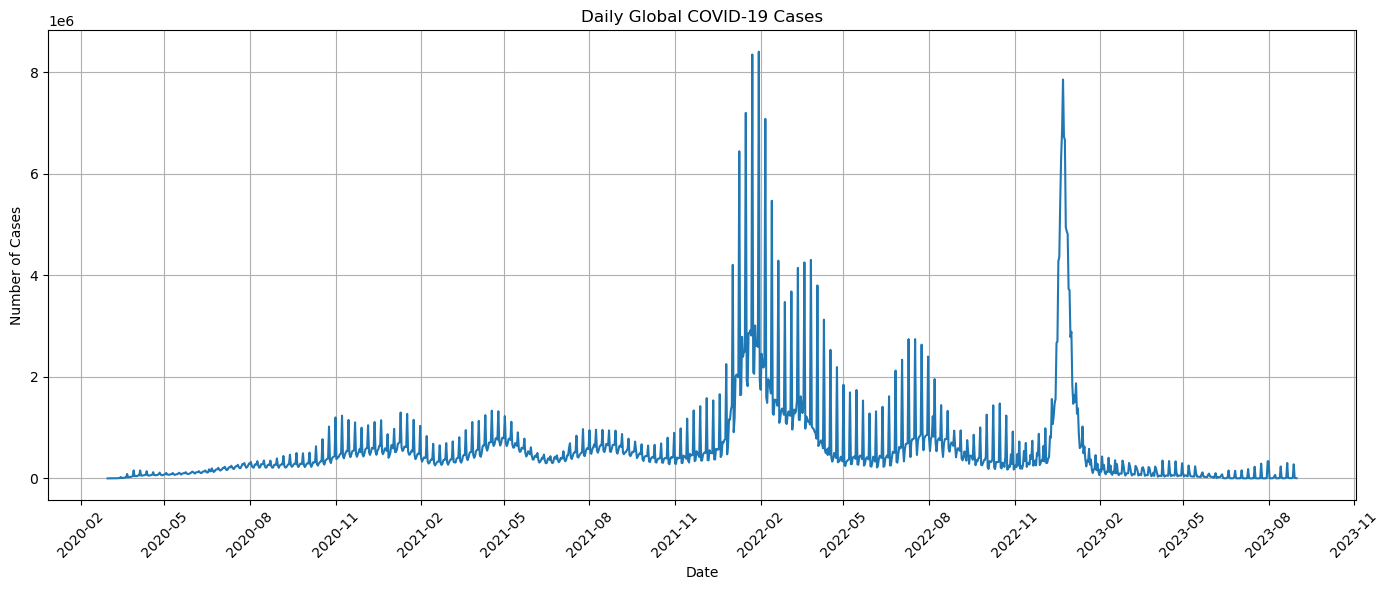

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

daily_global_cases = (
    df_covid_trimmed.groupby('Date_reported')['New_cases']
    .sum()
)

plt.figure(figsize=(14,6))

plt.plot(
    daily_global_cases.index,
    daily_global_cases.values
)

plt.title('Daily Global COVID-19 Cases')
plt.xlabel('Date')
plt.ylabel('Number of Cases')

# Show date every 3 months
plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    'daily_global_cases.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

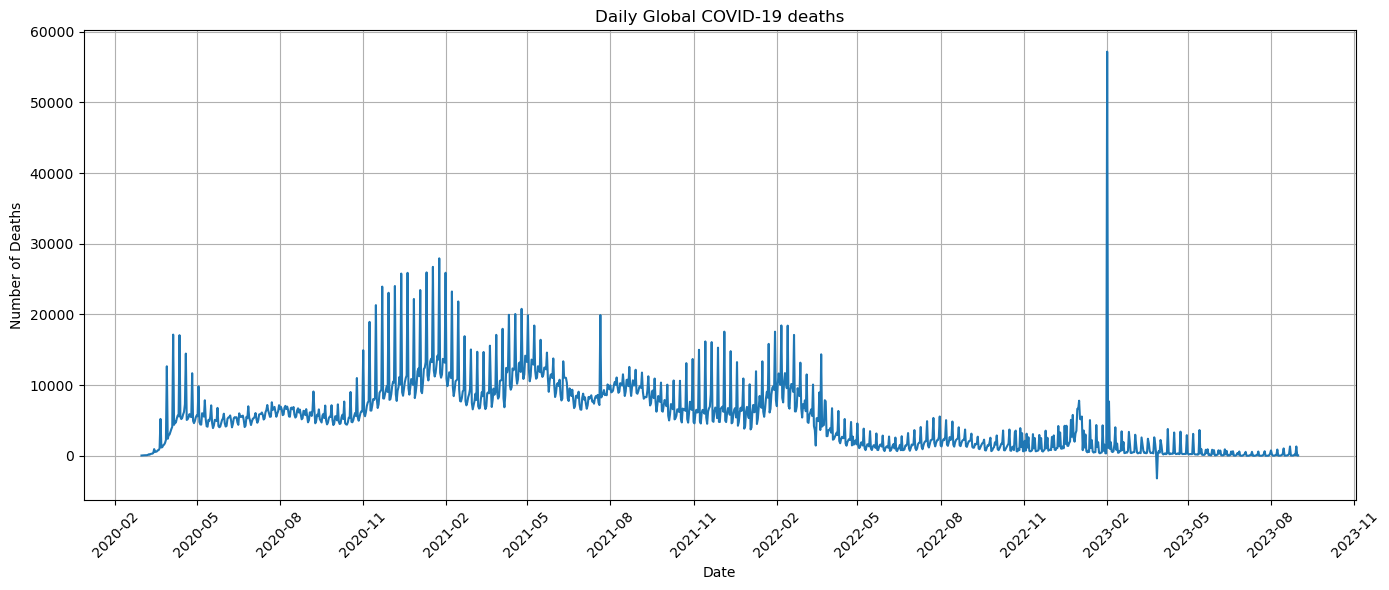

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

daily_global_cases = (
    df_covid_trimmed.groupby('Date_reported')['New_deaths']
    .sum()
)

plt.figure(figsize=(14,6))

plt.plot(
    daily_global_cases.index,
    daily_global_cases.values
)

plt.title('Daily Global COVID-19 deaths')
plt.xlabel('Date')
plt.ylabel('Number of Deaths')

# Show date every 3 months
plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    'daily_global_cases.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

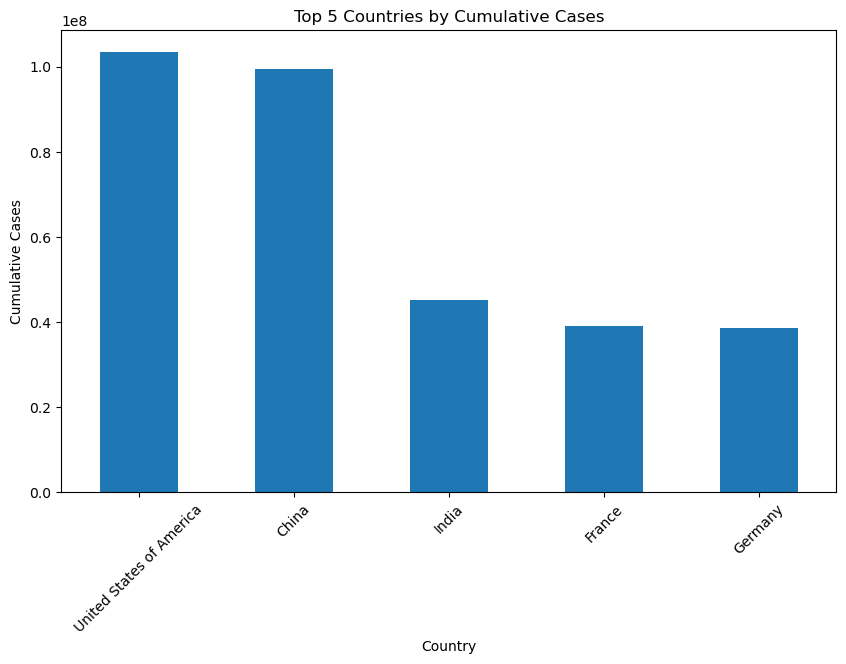

In [17]:
top5 = (
    df_covid.groupby('Country')['Cumulative_cases']
    .max()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10,6))

top5.plot(kind='bar')

plt.title('Top 5 Countries by Cumulative Cases')
plt.xlabel('Country')
plt.ylabel('Cumulative Cases')

plt.xticks(rotation=45)

plt.savefig('top5_countries.png',
            bbox_inches='tight')

plt.show()

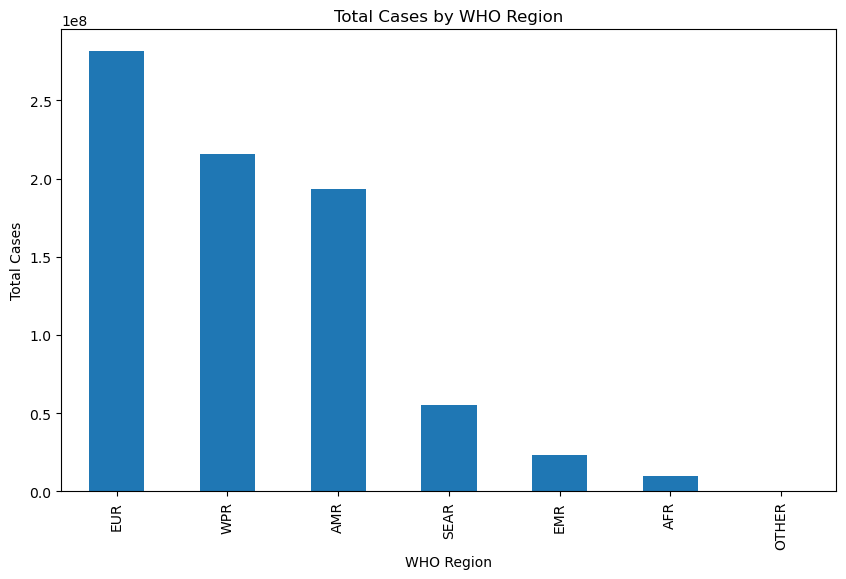

In [18]:
region_cases = (
    df_covid.groupby('WHO_region')
    ['New_cases']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

region_cases.plot(kind='bar')

plt.title('Total Cases by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Total Cases')

plt.savefig('who_region_cases.png',
            bbox_inches='tight')

plt.show()

C:\Users\Debopriyo Bhar\AppData\Local\Temp\ipykernel_19064\2060918492.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_covid_trimmed['Quarter'] = (


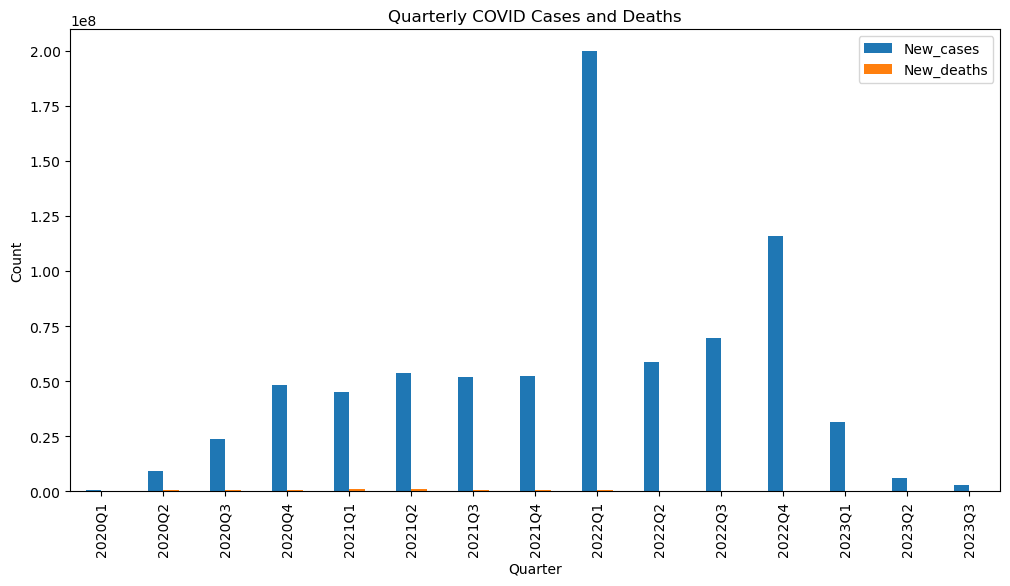

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_covid_trimmed['Quarter'] = (
    df_covid_trimmed['Date_reported']
    .dt.to_period('Q')
)

quarterly_data = (
    df_covid_trimmed
    .groupby('Quarter')
    [['New_cases','New_deaths']]
    .sum()
)

quarterly_data.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Quarterly COVID Cases and Deaths')
plt.xlabel('Quarter')
plt.ylabel('Count')

plt.savefig('quarterly_cases_deaths.png',
            bbox_inches='tight')

plt.show()

C:\Users\Debopriyo Bhar\AppData\Local\Temp\ipykernel_19064\2892782408.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_covid_trimmed['Month_Year'] = (


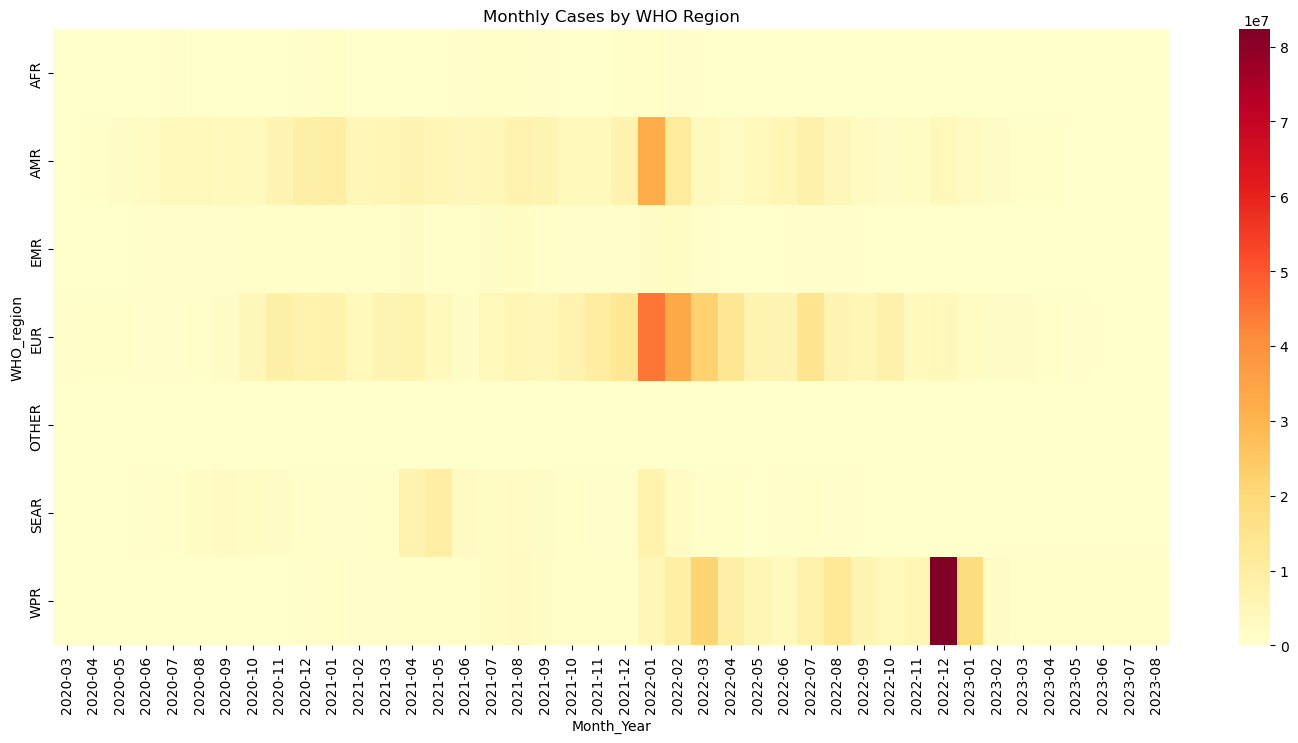

In [20]:
import seaborn as sns

df_covid_trimmed['Month_Year'] = (
    df_covid_trimmed['Date_reported']
    .dt.to_period('M')
)

pivot_table = pd.pivot_table(
    df_covid_trimmed,
    values='New_cases',
    index='WHO_region',
    columns='Month_Year',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(18,8))

sns.heatmap(
    pivot_table,
    cmap='YlOrRd'
)

plt.title('Monthly Cases by WHO Region')

plt.savefig('monthly_cases_region.png',
            bbox_inches='tight')

plt.show()

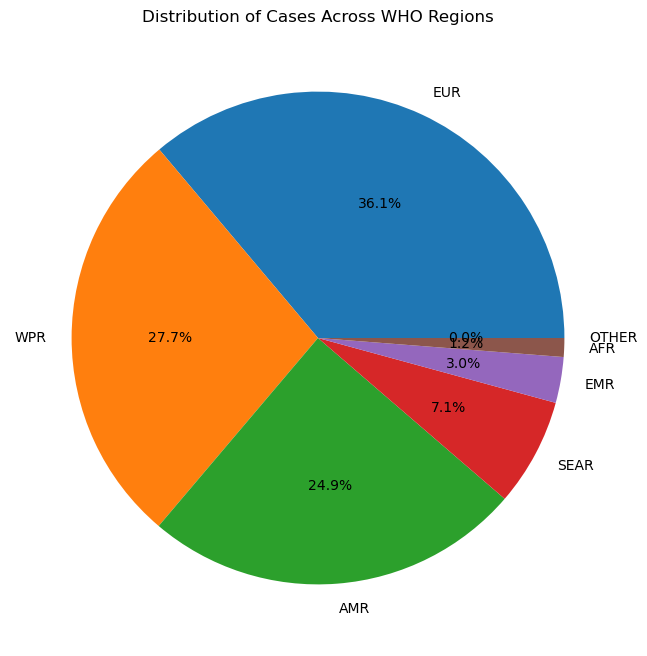

In [21]:
plt.figure(figsize=(8,8))

region_cases.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')

plt.title('Distribution of Cases Across WHO Regions')

plt.savefig('who_region_pie.png',
            bbox_inches='tight')

plt.show()

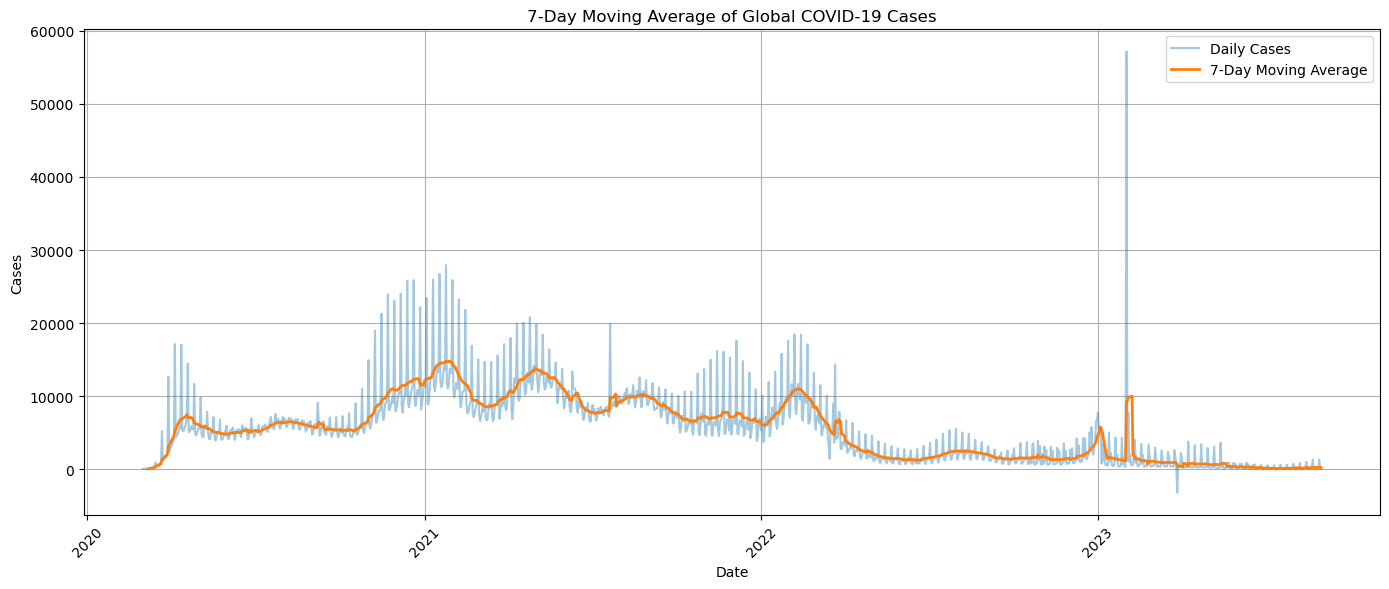

In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

moving_avg = (
    daily_global_cases
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(
    daily_global_cases.index,
    daily_global_cases.values,
    alpha=0.4,
    label='Daily Cases'
)

plt.plot(
    moving_avg.index,
    moving_avg.values,
    linewidth=2,
    label='7-Day Moving Average'
)

plt.title('7-Day Moving Average of Global COVID-19 Cases')

plt.xlabel('Date')
plt.ylabel('Cases')

# Show one label per year
plt.gca().xaxis.set_major_locator(
    mdates.YearLocator()
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    'moving_average.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

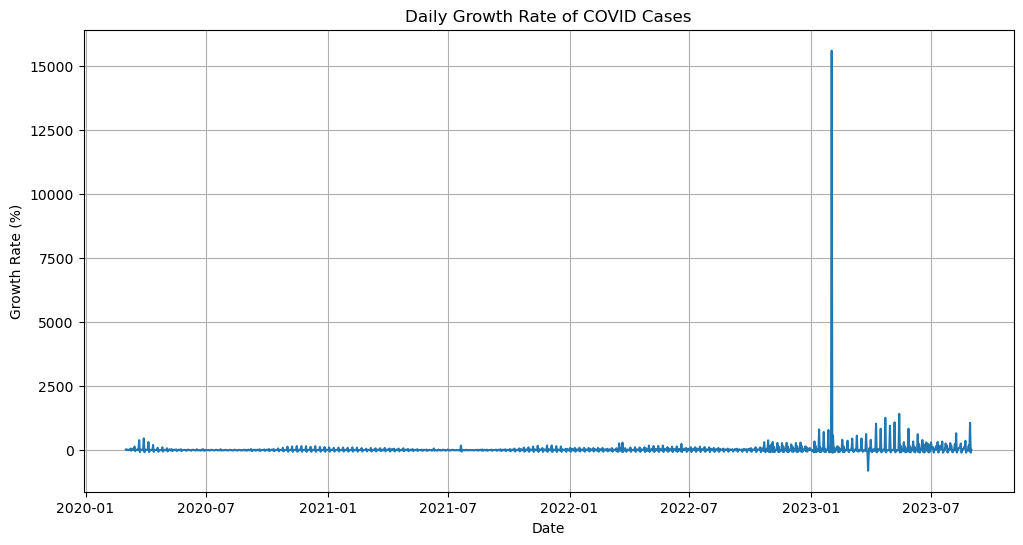

In [23]:
growth_rate = (
    daily_global_cases
    .pct_change() * 100
)

plt.figure(figsize=(12,6))

plt.plot(growth_rate)

plt.title('Daily Growth Rate of COVID Cases')

plt.xlabel('Date')
plt.ylabel('Growth Rate (%)')

plt.grid(True)

plt.savefig('growth_rate.png',
            bbox_inches='tight')

plt.show()

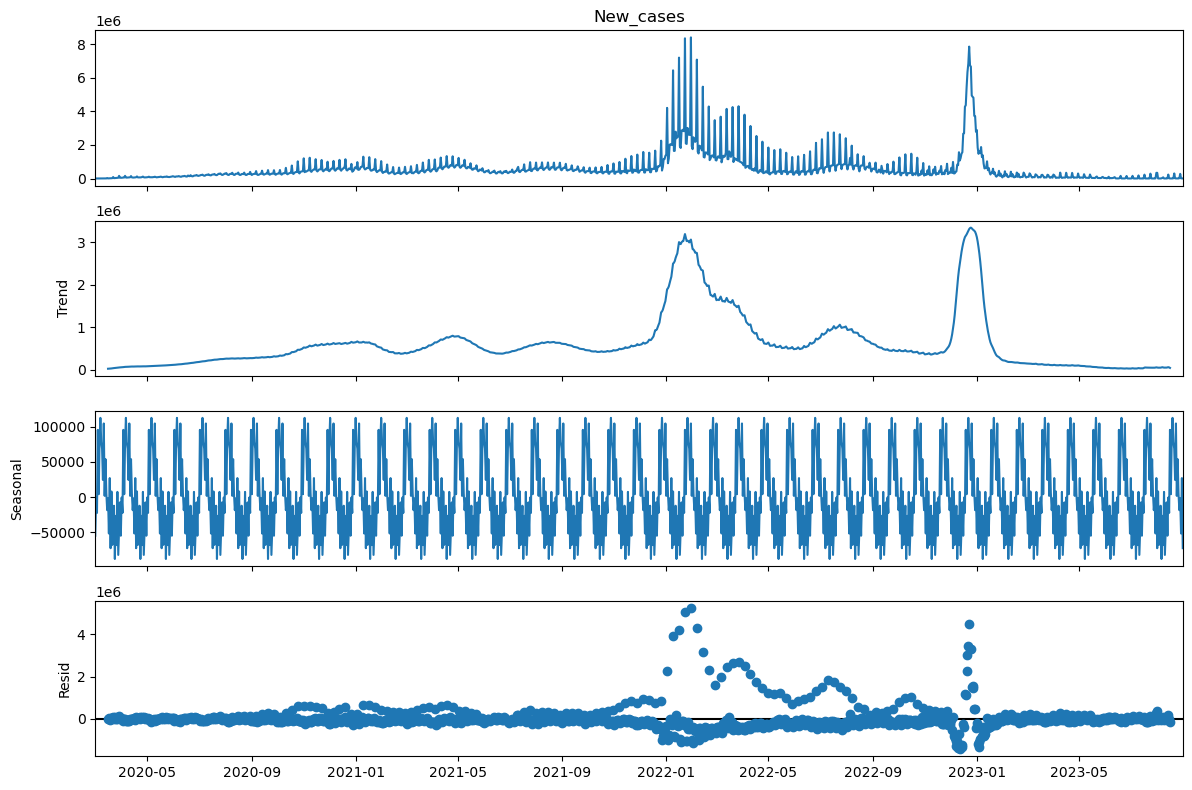

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Daily global cases
daily_global_cases = (
    df_covid_trimmed.groupby('Date_reported')['New_cases']
    .sum()
)

# Seasonal decomposition
decomposition = seasonal_decompose(
    daily_global_cases,
    model='additive',
    period=30
)

# Plot decomposition
fig = decomposition.plot()

fig.set_size_inches(12, 8)

plt.tight_layout()

plt.savefig(
    'seasonal_decomposition.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [25]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_global_cases)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

for key, value in result[4].items():
    print(key, value)

ADF Statistic: -3.8556744424911003
p-value: 0.0023863896273745777
1% -3.4355629707955395
5% -2.863842063387667
10% -2.567995644141416


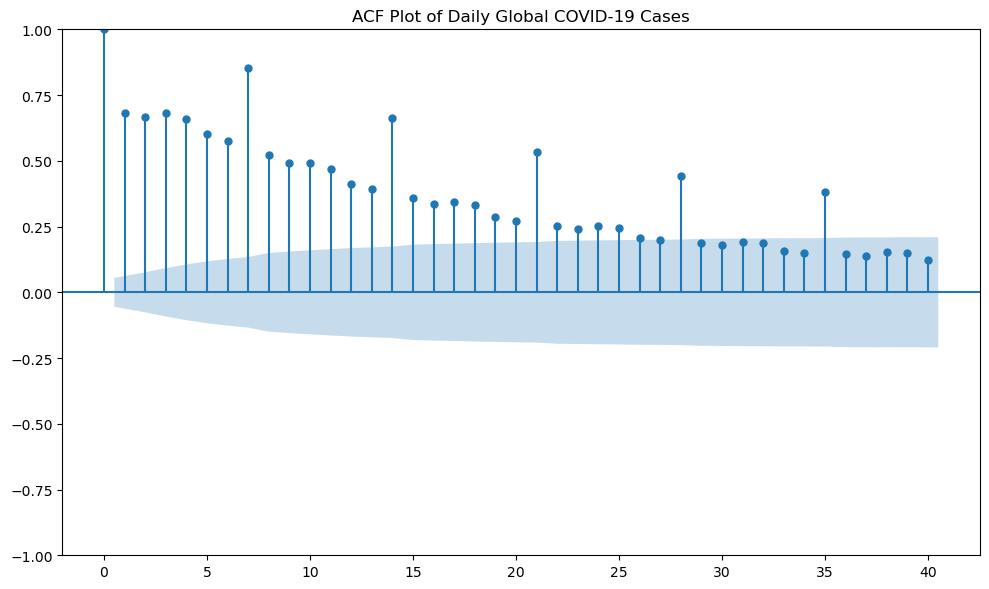

In [26]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))

plot_acf(
    daily_global_cases,
    lags=40,
    ax=ax
)

plt.title('ACF Plot of Daily Global COVID-19 Cases')

plt.tight_layout()

plt.savefig(
    'acf_plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<Figure size 1000x600 with 0 Axes>

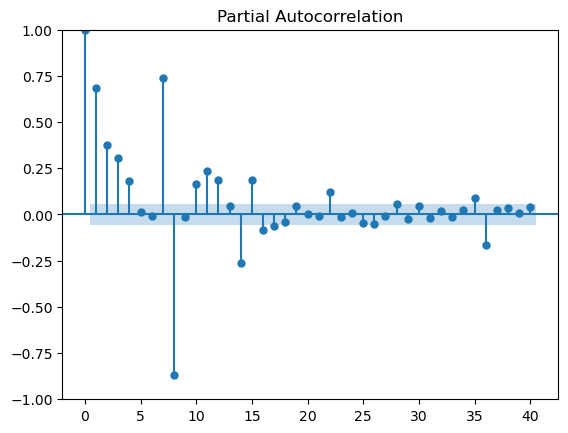

In [27]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,6))

plot_pacf(
    daily_global_cases,
    lags=40,
    method='ywm'
)

plt.savefig(
    'pacf_plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [28]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA(3,0,1)
arima_model = ARIMA(
    daily_global_cases,
    order=(3,0,1)
)

arima_result = arima_model.fit()

# Model summary
print(arima_result.summary())

c:\Users\Debopriyo Bhar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Debopriyo Bhar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Debopriyo Bhar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              New_cases   No. Observations:                 1279
Model:                 ARIMA(3, 0, 1)   Log Likelihood              -18747.509
Date:                Mon, 08 Jun 2026   AIC                          37507.017
Time:                        07:06:16   BIC                          37537.940
Sample:                    03-01-2020   HQIC                         37518.629
                         - 08-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.021e+05   2.68e-09   2.25e+14      0.000    6.02e+05    6.02e+05
ar.L1          0.8243      0.033     24.650      0.000       0.759       0.890
ar.L2          0.0265      0.021      1.274      0.2

In [29]:
print("AIC =", arima_result.aic)
print("BIC =", arima_result.bic)

AIC = 37507.01719853323
BIC = 37537.9402013427


In [30]:
forecast = arima_result.forecast(
    steps=30
)

print(forecast)

2023-09-01     96019.105908
2023-09-02    101630.767990
2023-09-03    108572.200074
2023-09-04    124683.016701
2023-09-05    138783.017813
2023-09-06    151619.290890
2023-09-07    164399.154835
2023-09-08    176871.239234
2023-09-09    188944.979466
2023-09-10    200675.809411
2023-09-11    212078.548966
2023-09-12    223156.626146
2023-09-13    233919.538746
2023-09-14    244376.885443
2023-09-15    254537.218685
2023-09-16    264408.918707
2023-09-17    274000.207466
2023-09-18    283319.053377
2023-09-19    292373.192151
2023-09-20    301170.143033
2023-09-21    309717.211936
2023-09-22    318021.496827
2023-09-23    326089.894083
2023-09-24    333929.104229
2023-09-25    341545.637450
2023-09-26    348945.818998
2023-09-27    356135.794460
2023-09-28    363121.534850
2023-09-29    369908.841574
2023-09-30    376503.351246
Freq: D, Name: predicted_mean, dtype: float64


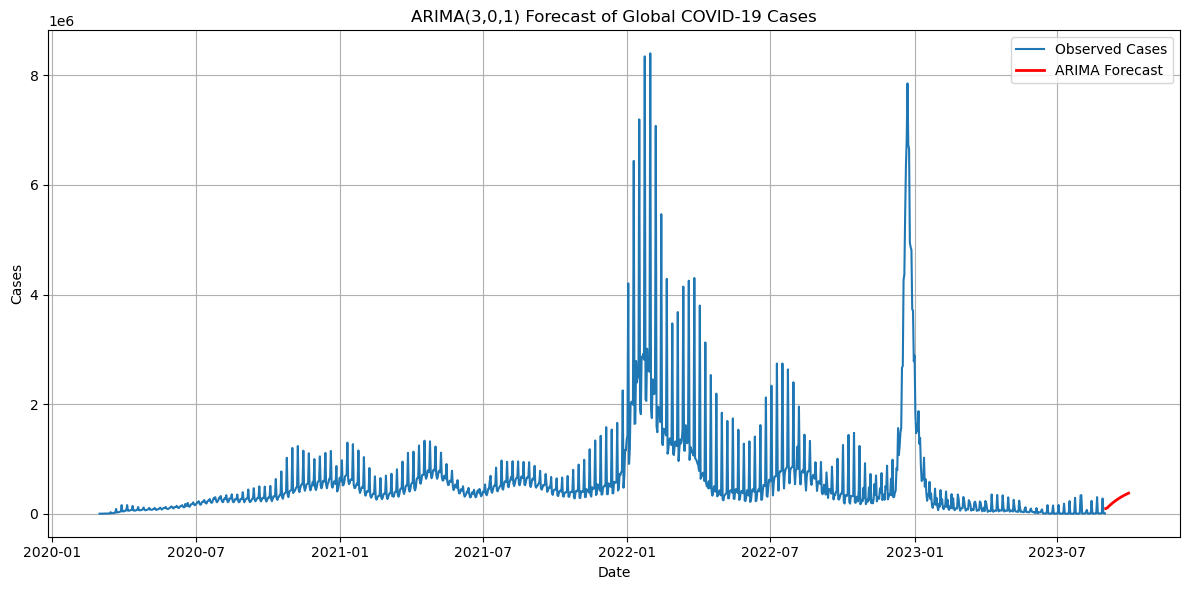

In [31]:
import matplotlib.pyplot as plt

forecast = arima_result.forecast(steps=30)

plt.figure(figsize=(12,6))

plt.plot(
    daily_global_cases,
    label='Observed Cases'
)

plt.plot(
    forecast.index,
    forecast,
    color='red',
    linewidth=2,
    label='ARIMA Forecast'
)

plt.title('ARIMA(3,0,1) Forecast of Global COVID-19 Cases')

plt.xlabel('Date')
plt.ylabel('Cases')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    'arima_forecast.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

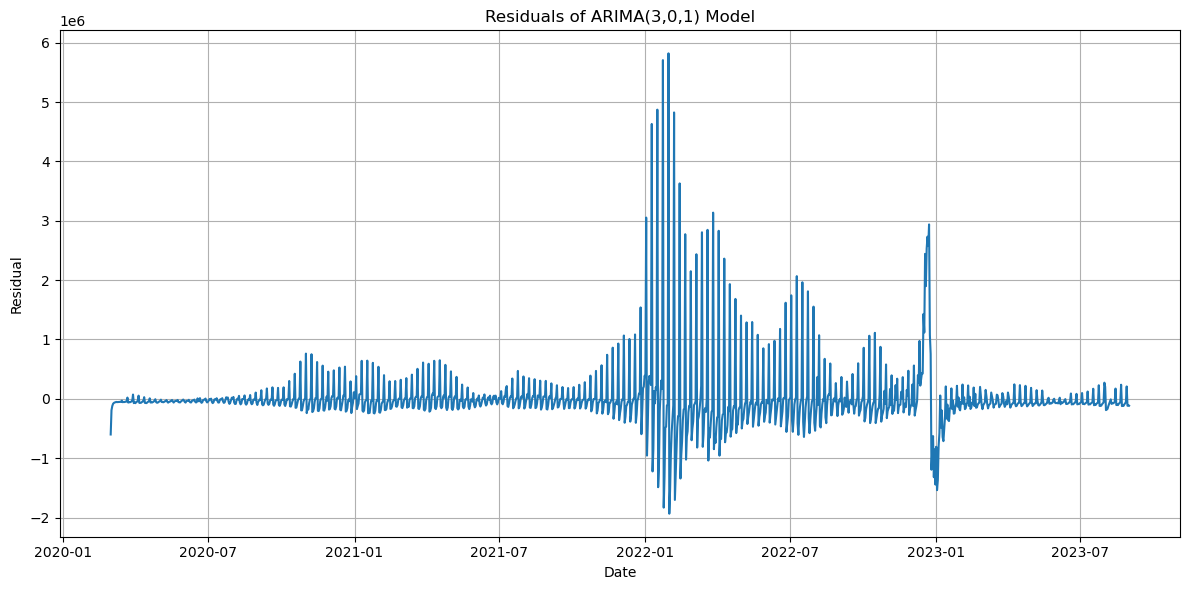

In [32]:
residuals = arima_result.resid

plt.figure(figsize=(12,6))

plt.plot(residuals)

plt.title('Residuals of ARIMA(3,0,1) Model')

plt.xlabel('Date')
plt.ylabel('Residual')

plt.grid(True)

plt.tight_layout()

plt.savefig(
    'arima_residuals.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

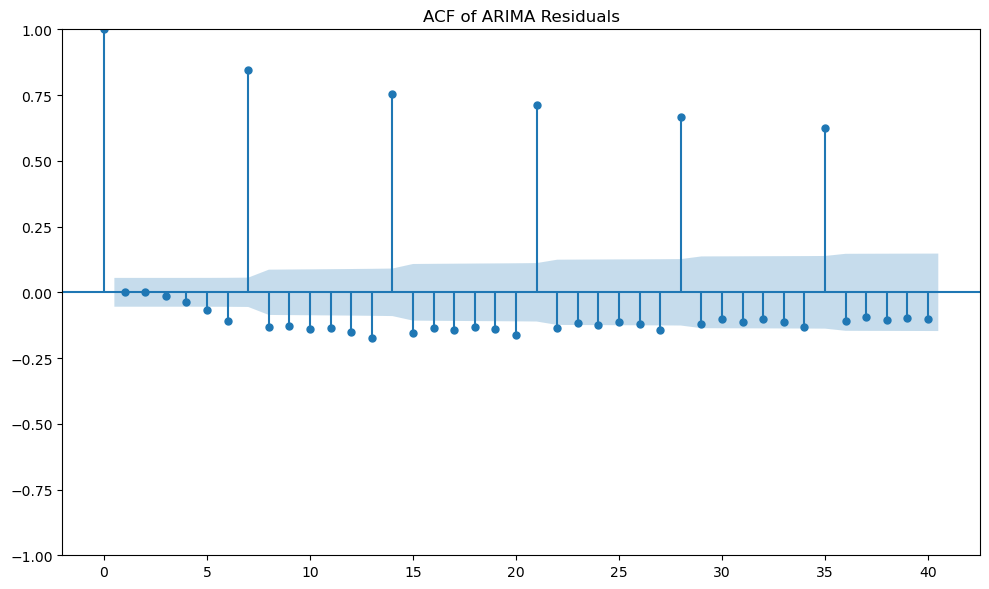

In [33]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10,6))

plot_acf(
    residuals,
    lags=40,
    ax=ax
)

plt.title('ACF of ARIMA Residuals')

plt.tight_layout()

plt.savefig(
    'arima_residual_acf.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [34]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# ARIMA residuals
residuals = arima_result.resid

lb_test = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)

print(lb_test)

        lb_stat      lb_pvalue
10  1014.431759  1.455238e-211


In [35]:
from scipy.stats import jarque_bera

jb_stat, jb_pvalue = jarque_bera(
    arima_result.resid
)

print("Jarque-Bera Statistic =", jb_stat)
print("p-value =", jb_pvalue)

Jarque-Bera Statistic = 73913.56712237278
p-value = 0.0


In [36]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    daily_global_cases,
    order=(3,0,1),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

c:\Users\Debopriyo Bhar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Debopriyo Bhar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                         New_cases   No. Observations:                 1279
Model:             SARIMAX(3, 0, 1)x(1, 0, 1, 7)   Log Likelihood              -18061.717
Date:                           Mon, 08 Jun 2026   AIC                          36137.435
Time:                                   07:06:21   BIC                          36173.457
Sample:                               03-01-2020   HQIC                         36150.966
                                    - 08-31-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4759      0.261      5.663      0.000       0.965       1.987
ar.L2         -0.3046      0.396     -0.770

In [37]:
print("SARIMA AIC =", sarima_result.aic)
print("SARIMA BIC =", sarima_result.bic)

SARIMA AIC = 36137.43468838048
SARIMA BIC = 36173.456579654485


In [38]:
sarima_forecast = sarima_result.forecast(
    steps=30
)

print(sarima_forecast)

2023-09-01      5009.076691
2023-09-02      5911.979108
2023-09-03     21102.089484
2023-09-04    263255.061799
2023-09-05     13002.785896
2023-09-06      6638.752207
2023-09-07      5794.408600
2023-09-08      5215.891134
2023-09-09      5998.452114
2023-09-10     20415.349761
2023-09-11    251369.064394
2023-09-12     12512.583668
2023-09-13      6359.280646
2023-09-14      5483.083929
2023-09-15      4874.192188
2023-09-16      5579.445407
2023-09-17     19309.404894
2023-09-18    239655.943970
2023-09-19     11762.606816
2023-09-20      5906.521536
2023-09-21      5094.057217
2023-09-22      4542.385597
2023-09-23      5247.465455
2023-09-24     18379.918183
2023-09-25    228646.655194
2023-09-26     11236.719612
2023-09-27      5671.159174
2023-09-28      4912.097651
2023-09-29      4395.929373
2023-09-30      5073.119619
Freq: D, Name: predicted_mean, dtype: float64


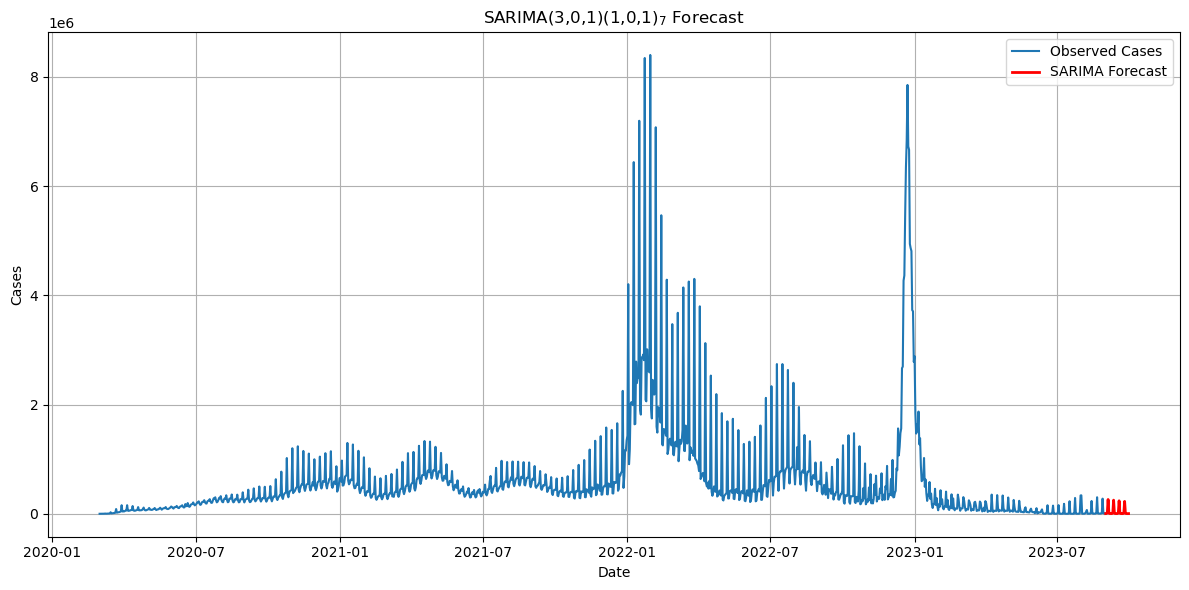

In [39]:
import matplotlib.pyplot as plt

sarima_forecast = sarima_result.forecast(
    steps=30
)

plt.figure(figsize=(12,6))

plt.plot(
    daily_global_cases,
    label='Observed Cases'
)

plt.plot(
    sarima_forecast.index,
    sarima_forecast,
    color='red',
    linewidth=2,
    label='SARIMA Forecast'
)

plt.title('SARIMA(3,0,1)(1,0,1)$_7$ Forecast')

plt.xlabel('Date')
plt.ylabel('Cases')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    'sarima_forecast.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

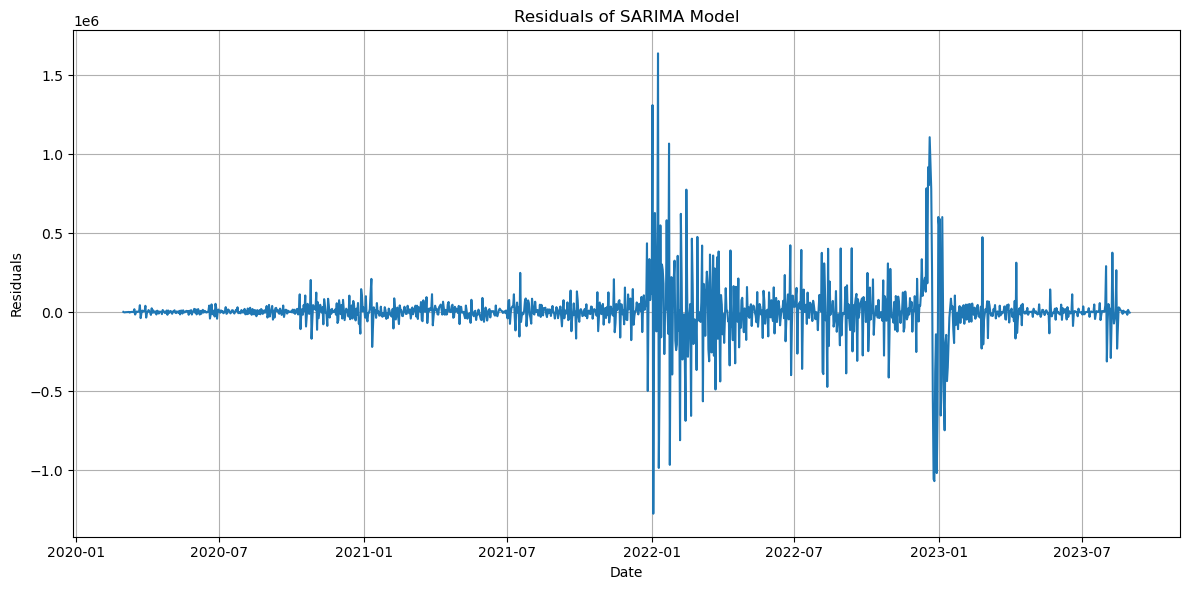

In [40]:
residuals = sarima_result.resid

plt.figure(figsize=(12,6))

plt.plot(residuals)

plt.title('Residuals of SARIMA Model')

plt.xlabel('Date')
plt.ylabel('Residuals')

plt.grid(True)

plt.tight_layout()

plt.savefig(
    'sarima_residuals.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

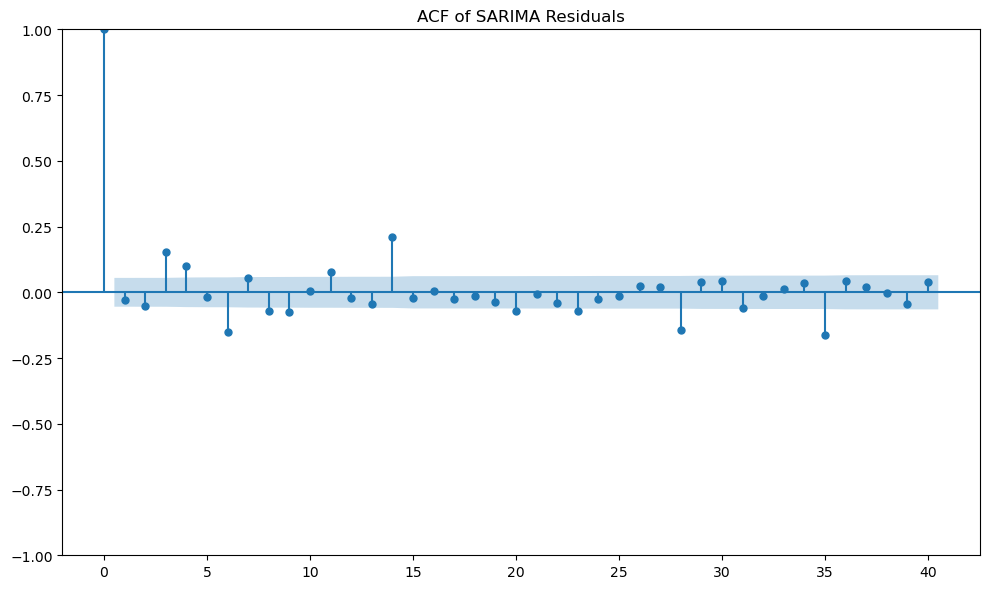

In [41]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10,6))

plot_acf(
    residuals,
    lags=40,
    ax=ax
)

plt.title('ACF of SARIMA Residuals')

plt.tight_layout()

plt.savefig(
    'sarima_residual_acf.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [42]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)

print(lb_test)

      lb_stat     lb_pvalue
10  95.536228  4.246481e-16


In [59]:
from scipy.stats import jarque_bera

jb_stat, jb_pvalue = jarque_bera(
    sarima_result.resid
)

print("Jarque-Bera Statistic =", jb_stat)
print("p-value =", jb_pvalue)

Jarque-Bera Statistic = 25838.949754470792
p-value = 0.0


In [43]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    daily_global_cases,
    trend='add',
    seasonal='add',
    seasonal_periods=7
)

hw_result = hw_model.fit()

print(hw_result.summary())

c:\Users\Debopriyo Bhar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                       ExponentialSmoothing Model Results                       
Dep. Variable:                New_cases   No. Observations:                 1279
Model:             ExponentialSmoothing   SSE                 69687284598035.688
Optimized:                         True   AIC                          31640.421
Trend:                         Additive   BIC                          31697.114
Seasonal:                      Additive   AICC                         31640.709
Seasonal Periods:                     7   Date:                 Mon, 08 Jun 2026
Box-Cox:                          False   Time:                         07:06:25
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.4292857                alpha                 True
smoothing_trend          

c:\Users\Debopriyo Bhar\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [44]:
hw_forecast = hw_result.forecast(30)

print(hw_forecast)

2023-09-01     10400.391382
2023-09-02      5526.200533
2023-09-03     13867.750712
2023-09-04    263222.620702
2023-09-05      -932.418983
2023-09-06      3726.804082
2023-09-07     19754.925917
2023-09-08     14979.802347
2023-09-09     10105.611498
2023-09-10     18447.161677
2023-09-11    267802.031667
2023-09-12      3646.991982
2023-09-13      8306.215047
2023-09-14     24334.336882
2023-09-15     19559.213312
2023-09-16     14685.022463
2023-09-17     23026.572642
2023-09-18    272381.442633
2023-09-19      8226.402947
2023-09-20     12885.626012
2023-09-21     28913.747847
2023-09-22     24138.624277
2023-09-23     19264.433428
2023-09-24     27605.983607
2023-09-25    276960.853598
2023-09-26     12805.813912
2023-09-27     17465.036977
2023-09-28     33493.158812
2023-09-29     28718.035242
2023-09-30     23843.844393
Freq: D, dtype: float64


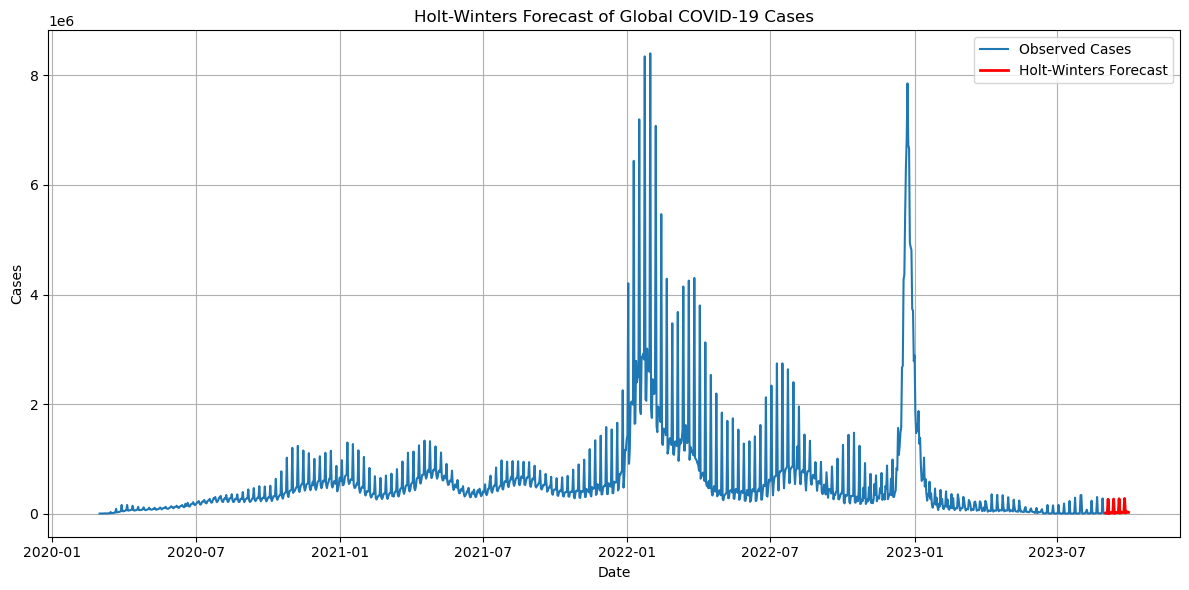

In [45]:
import matplotlib.pyplot as plt

hw_forecast = hw_result.forecast(30)

plt.figure(figsize=(12,6))

plt.plot(
    daily_global_cases,
    label='Observed Cases'
)

plt.plot(
    hw_forecast.index,
    hw_forecast,
    color='red',
    linewidth=2,
    label='Holt-Winters Forecast'
)

plt.title('Holt-Winters Forecast of Global COVID-19 Cases')

plt.xlabel('Date')
plt.ylabel('Cases')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    'holt_winters_forecast.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

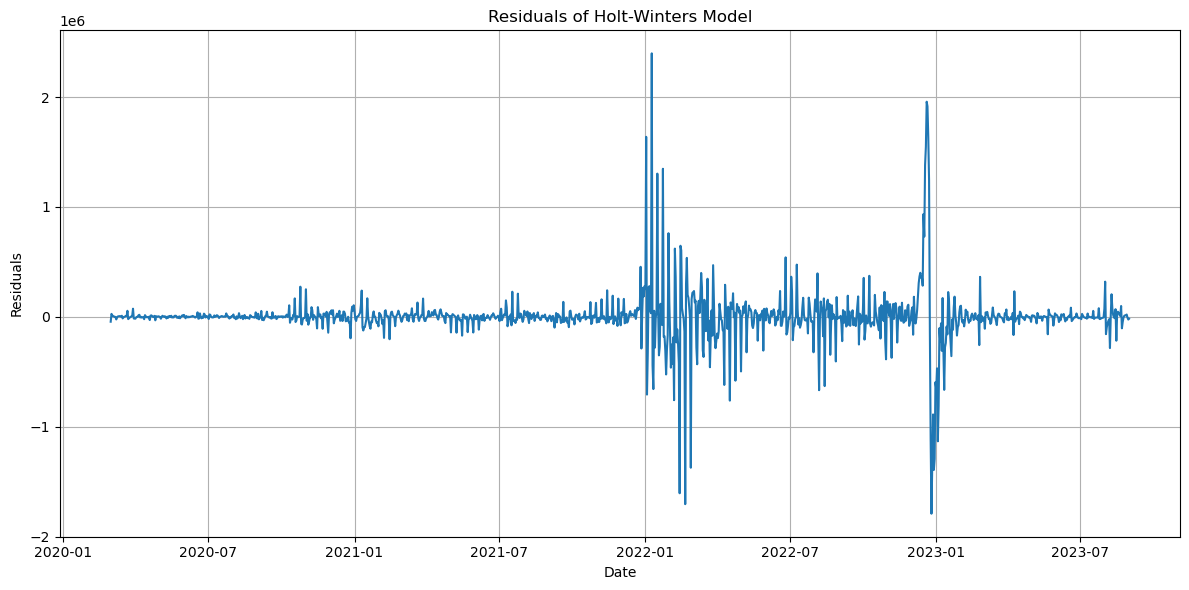

In [46]:
residuals = hw_result.resid

plt.figure(figsize=(12,6))

plt.plot(residuals)

plt.title('Residuals of Holt-Winters Model')

plt.xlabel('Date')
plt.ylabel('Residuals')

plt.grid(True)

plt.tight_layout()

plt.savefig(
    'holt_winters_residuals.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [47]:
print("AIC =", hw_result.aic)
print("BIC =", hw_result.bic)
print("SSE =", hw_result.sse)

AIC = 31640.4214316527
BIC = 31697.11360347007
SSE = 69687284598035.69


In [48]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)

print(lb_test)

       lb_stat      lb_pvalue
10  545.745623  7.292275e-111


In [49]:
from scipy.stats import jarque_bera

jb_stat, jb_pvalue = jarque_bera(residuals)

print("JB Statistic =", jb_stat)
print("p-value =", jb_pvalue)

JB Statistic = 63520.80789628527
p-value = 0.0


In [50]:
print(hw_result.summary())
print("AIC =", hw_result.aic)
print("BIC =", hw_result.bic)

                       ExponentialSmoothing Model Results                       
Dep. Variable:                New_cases   No. Observations:                 1279
Model:             ExponentialSmoothing   SSE                 69687284598035.688
Optimized:                         True   AIC                          31640.421
Trend:                         Additive   BIC                          31697.114
Seasonal:                      Additive   AICC                         31640.709
Seasonal Periods:                     7   Date:                 Mon, 08 Jun 2026
Box-Cox:                          False   Time:                         07:06:27
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.4292857                alpha                 True
smoothing_trend          

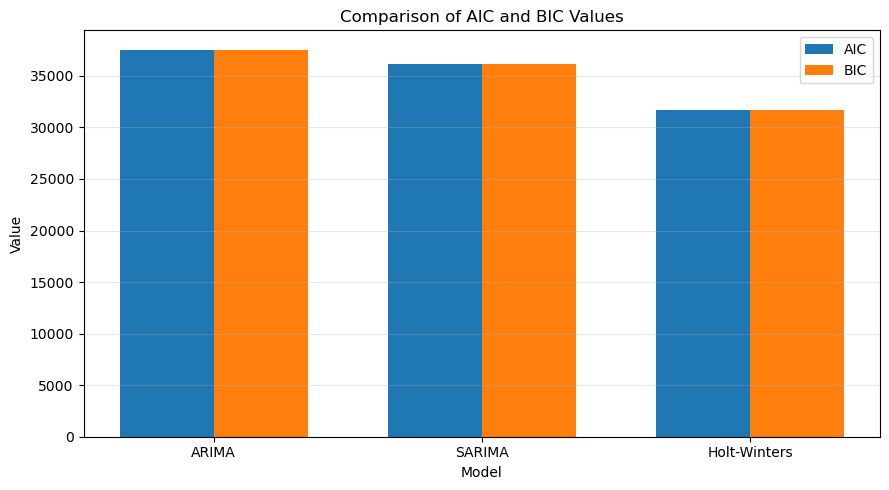

In [61]:
import numpy as np
import matplotlib.pyplot as plt

models = ['ARIMA', 'SARIMA', 'Holt-Winters']

aic = [37507.017, 36137.435, 31640.421]
bic = [37537.940, 36173.457, 31697.114]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(
    x - width/2,
    aic,
    width,
    label='AIC'
)

plt.bar(
    x + width/2,
    bic,
    width,
    label='BIC'
)

plt.xticks(x, models)

plt.ylabel('Value')
plt.xlabel('Model')

plt.title('Comparison of AIC and BIC Values')

plt.legend()

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    'model_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

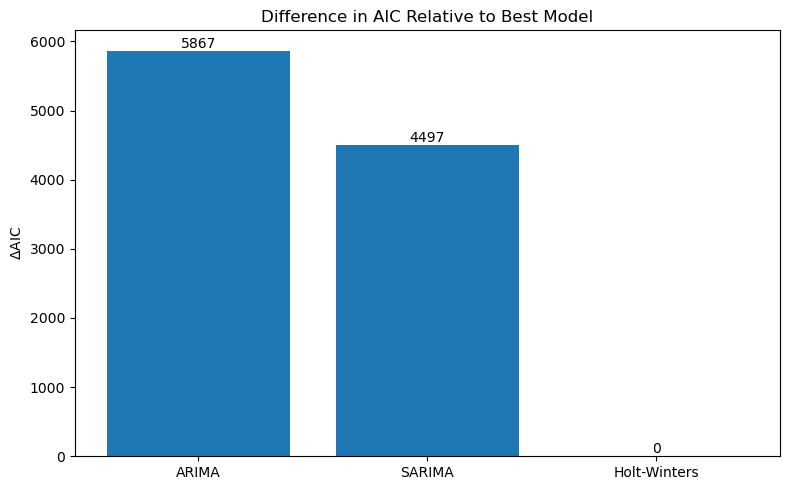

In [62]:
import matplotlib.pyplot as plt

models = ['ARIMA', 'SARIMA', 'Holt-Winters']

aic = [37507.017, 36137.435, 31640.421]

best_aic = min(aic)

delta_aic = [x - best_aic for x in aic]

plt.figure(figsize=(8,5))

bars = plt.bar(models, delta_aic)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{y:.0f}',
        ha='center',
        va='bottom'
    )

plt.ylabel(r'$\Delta$AIC')
plt.title('Difference in AIC Relative to Best Model')

plt.tight_layout()

plt.savefig(
    'delta_aic.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [51]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1797, 64)
Shape of y: (1797,)


In [52]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

kmeans_labels = kmeans.labels_

print(kmeans_labels)

c:\Users\Debopriyo Bhar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


[1 3 3 ... 3 8 8]


In [53]:
from scipy.stats import mode
from sklearn.metrics import f1_score
import numpy as np

mapped_labels = np.zeros_like(kmeans_labels)

for i in range(10):
    mask = (kmeans_labels == i)

    if np.sum(mask) > 0:
        mapped_labels[mask] = mode(
            y[mask],
            keepdims=True
        )[0][0]

f1 = f1_score(
    y,
    mapped_labels,
    average='macro'
)

print("Macro F1 Score:", f1)

Macro F1 Score: 0.7894620863890832


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [55]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=10,
    linkage='ward'
)

hc_labels = hc.fit_predict(X_scaled)

print(hc_labels)

[5 1 1 ... 1 1 1]


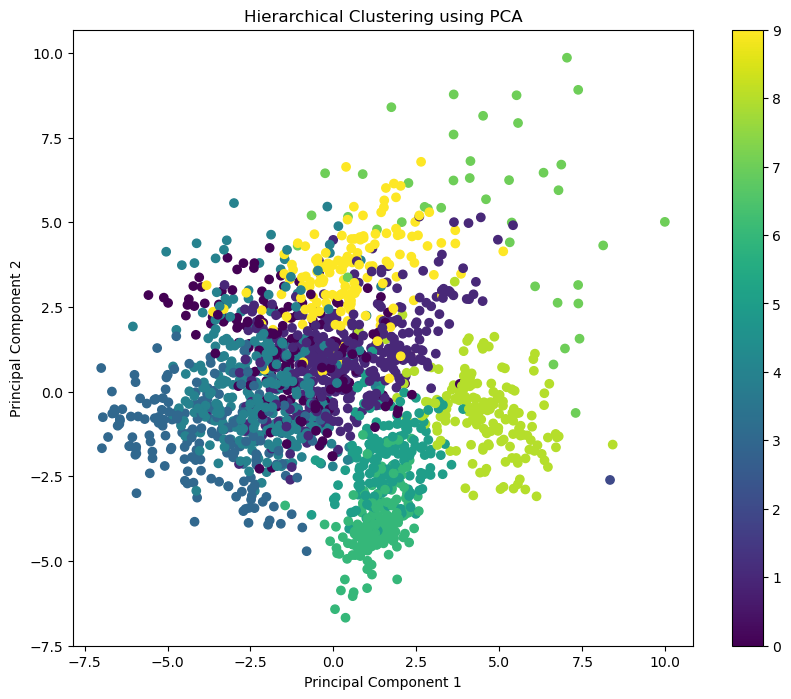

In [56]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hc_labels
)

plt.title('Hierarchical Clustering using PCA')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.colorbar(scatter)

plt.savefig(
    'hierarchical_pca.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

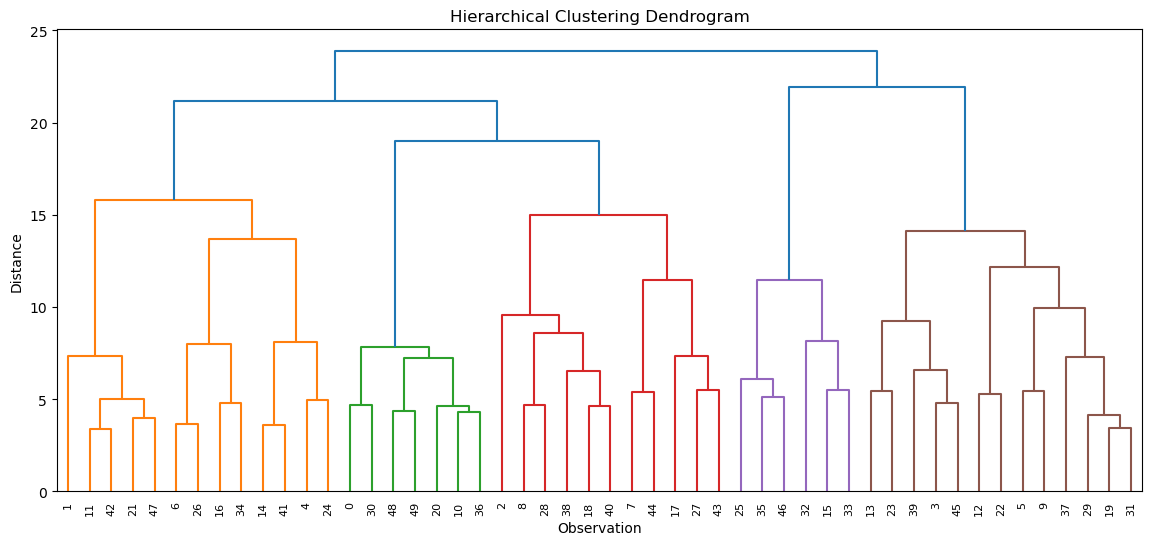

In [57]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

sample = X_scaled[:50]

Z = linkage(
    sample,
    method='ward'
)

plt.figure(figsize=(14,6))

dendrogram(
    Z,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Observation')
plt.ylabel('Distance')

plt.show()

In [58]:
from scipy.stats import mode
from sklearn.metrics import f1_score
import numpy as np

mapped_labels = np.zeros_like(hc_labels)

for i in range(10):

    mask = (hc_labels == i)

    if np.sum(mask) > 0:

        mapped_labels[mask] = mode(
            y[mask],
            keepdims=True
        )[0][0]

f1 = f1_score(
    y,
    mapped_labels,
    average='macro'
)

print("Macro F1 Score =", f1)

Macro F1 Score = 0.6949195013016611
